# Notebook 02: Dataset Labeling, Stratified Splitting, and Dual-Path Preprocessing

**Deskripsi:** Notebook ini memuat dataset tersaring dari Notebook 01, memberikan label otomatis 5 kelas emosi (*Joy, Anger, Sadness, Fear, Disgust*) menggunakan pendekatan leksikon leksikal (Resolusi Konflik: *Anger > Sadness > Disgust > Fear > Joy*), melakukan pembagian data secara stratifikasi (*Stratified Split* 70:15:15) untuk mencegah kebocoran data (*data leakage*), dan memproses teks secara bercabang untuk representasi TF-IDF (stemming + stopword kustom) dan Word2Vec (normalisasi slang saja).

In [1]:
import sys
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Tambahkan path parent directory agar modul 'src' bisa diimpor
sys.path.append(os.path.abspath('../'))
from src.preprocessing import (
    assign_lexicon_labels,
    preprocess_for_tfidf,
    preprocess_for_word2vec
)

# Buat direktori laporan gambar jika belum ada
os.makedirs('../reports/figures', exist_ok=True)
print("Modul preprocessing berhasil diimpor dan folder figures siap!")

Modul preprocessing berhasil diimpor dan folder figures siap!


## 1. Memuat Ulasan Tersaring dan Menjalankan Pelabelan Leksikon

In [2]:
filtered_csv_path = '../data/processed/filtered_reviews.csv'
df_filtered = pd.read_csv(filtered_csv_path)

# Hapus baris kosong jika ada
df_filtered = df_filtered.dropna(subset=['cleaned_content'])

print(f"Memulai pelabelan pada {len(df_filtered)} baris data...")
df_labeled = assign_lexicon_labels(df_filtered)

Memulai pelabelan pada 43583 baris data...


Data berlabel berhasil dibuat: 18247 baris.
emotion
joy        7748
anger      6174
sadness    1688
fear       1642
disgust     995
Name: count, dtype: int64


## 1.1 Visualisasi Sebaran Kelas dan Awan Kata (Word Clouds)

Kami menggambar visualisasi distribusi kelas emosi untuk menganalisis ketidakseimbangan kelas (*class imbalance*) dan menghasilkan Awan Kata (*Word Clouds*) untuk memvalidasi secara visual keabsahan kata kunci yang terasosiasi dengan kelima kelas emosi. Gambar visualisasi akan otomatis disimpan di folder `reports/figures/`.

Grafik distribusi kelas disimpan ke: reports/figures/class_distribution.png


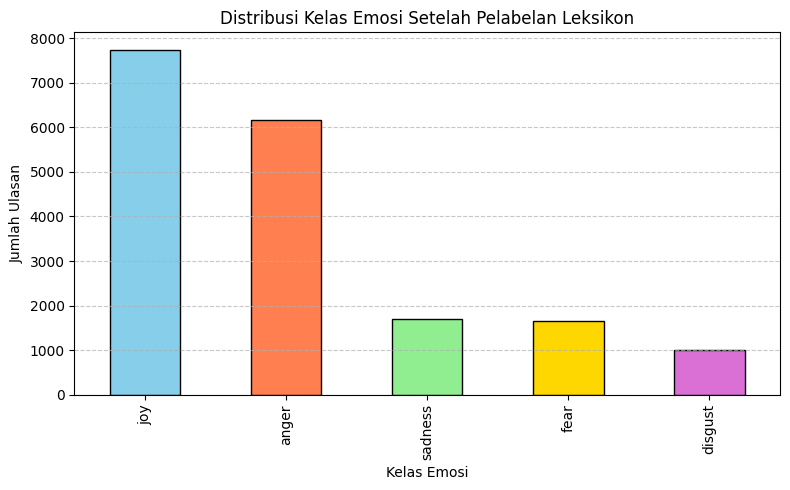

Gambar word clouds disimpan ke: reports/figures/wordclouds.png


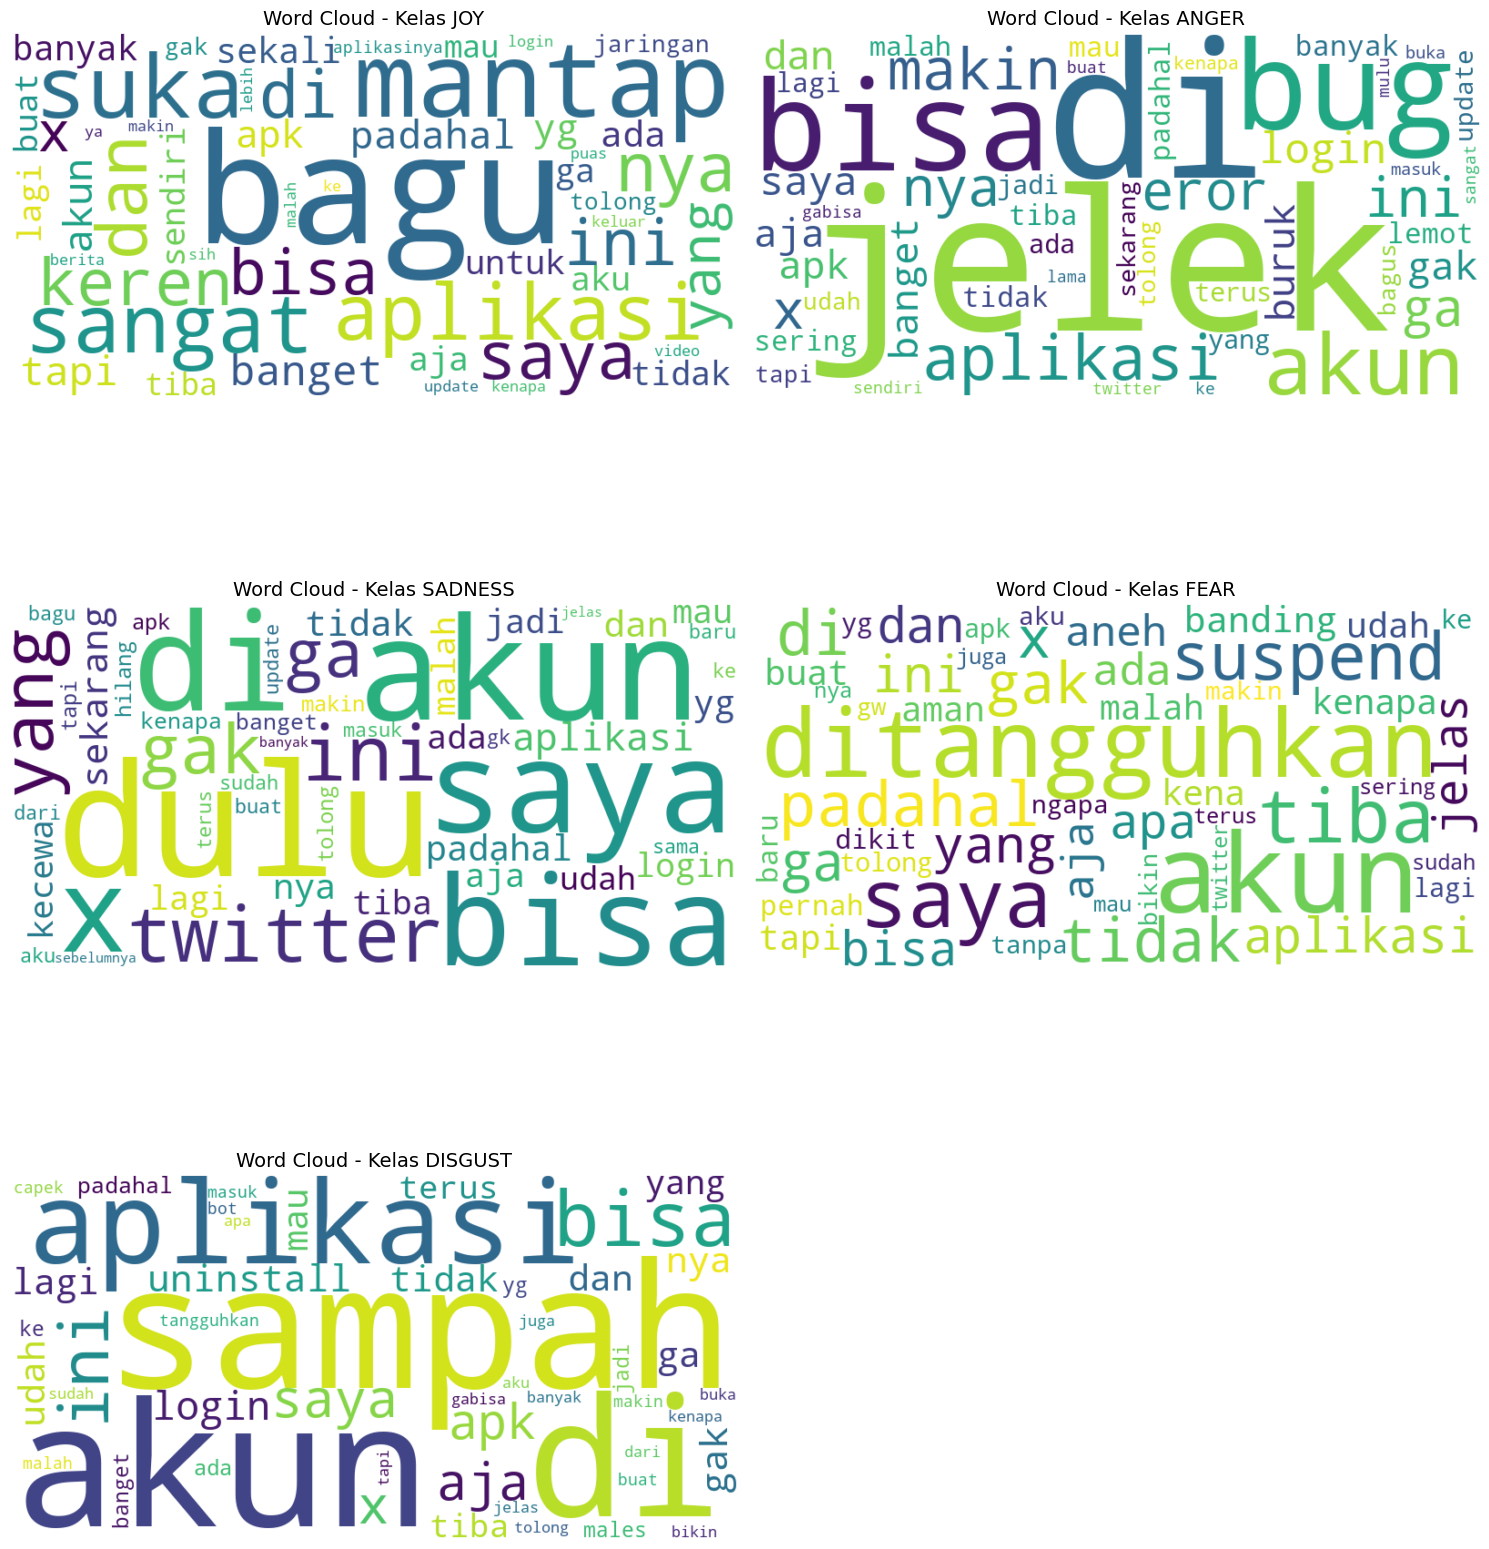

In [3]:
import matplotlib.pyplot as plt

# 1. Plot Sebaran Distribusi Kelas Labeled
plt.figure(figsize=(8, 5))
emotion_counts = df_labeled['emotion'].value_counts()
emotion_counts.plot(kind='bar', color=['skyblue', 'coral', 'lightgreen', 'gold', 'orchid'], edgecolor='black')
plt.title('Distribusi Kelas Emosi Setelah Pelabelan Leksikon')
plt.xlabel('Kelas Emosi')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=300, bbox_inches='tight')
print("Grafik distribusi kelas disimpan ke: reports/figures/class_distribution.png")
plt.show()

# 2. Awan Kata per Kelas Emosi (dengan fallback jika library 'wordcloud' belum terinstal)
try:
    from wordcloud import WordCloud
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    axes = axes.flatten()
    
    classes = ['joy', 'anger', 'sadness', 'fear', 'disgust']
    for idx, emo in enumerate(classes):
        emo_text = " ".join(df_labeled[df_labeled['emotion'] == emo]['cleaned_content'].astype(str))
        wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50, collocations=False).generate(emo_text)
        
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f"Word Cloud - Kelas {emo.upper()}", fontsize=14)
        axes[idx].axis('off')
        
    # Hapus subplot ke-6 yang tidak terpakai
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.savefig('../reports/figures/wordclouds.png', dpi=300, bbox_inches='tight')
    print("Gambar word clouds disimpan ke: reports/figures/wordclouds.png")
    plt.show()
    
except ImportError:
    print("[WARNING] Pustaka 'wordcloud' tidak terinstal. Menampilkan kata kunci terpopuler secara tekstual:")
    from collections import Counter
    classes = ['joy', 'anger', 'sadness', 'fear', 'disgust']
    for emo in classes:
        emo_text = " ".join(df_labeled[df_labeled['emotion'] == emo]['cleaned_content'].astype(str))
        words = emo_text.split()
        most_common = Counter(words).most_common(15)
        print(f"Top 15 kata untuk kelas {emo.upper()}: {most_common}")
        print("-" * 50)


## 2. Pembagian Data secara Stratifikasi (*Stratified Train/Val/Test Split*)

Untuk memastikan evaluasi kita adil dan mencerminkan proporsi kelas emosi yang asli, pembagian data dilakukan secara stratifikasi berdasarkan label `emotion` yang baru dibuat.
Rasio pembagian: **70% Latih (Train), 15% Validasi (Val), dan 15% Uji (Test)**.

In [4]:
X = df_labeled.drop(columns=['emotion'])
y = df_labeled['emotion']

# Pertama: Pisahkan Train (70%) dan Sisa (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Kedua: Bagi Sisa (30%) menjadi Val (15%) dan Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Gabungkan kembali fitur dengan label untuk masing-masing split
train_df = X_train.copy()
train_df['emotion'] = y_train

val_df = X_val.copy()
val_df['emotion'] = y_val

test_df = X_test.copy()
test_df['emotion'] = y_test

print(f"Dimensi Train set : {train_df.shape}")
print(f"Dimensi Val set   : {val_df.shape}")
print(f"Dimensi Test set  : {test_df.shape}")

Dimensi Train set : (12772, 14)
Dimensi Val set   : (2737, 14)
Dimensi Test set  : (2738, 14)


## 3. Eksekusi Pra-Pengolahan Bercabang (*Dual-Path Preprocessing*)

Kita menjalankan fungsi preprocessing kustom pada masing-masing split untuk menghasilkan dua versi representasi teks:
* `content_tfidf`: Menggunakan stemming dan pembuangan stopword selektif.
* `content_w2v`: Tanpa stemming dan tanpa pembuangan stopword (hanya normalisasi slang).

In [5]:
print("Memproses pra-pengolahan teks untuk Train set...")
train_df['content_tfidf'] = train_df['cleaned_content'].apply(preprocess_for_tfidf)
train_df['content_w2v'] = train_df['cleaned_content'].apply(preprocess_for_word2vec)

print("Memproses pra-pengolahan teks untuk Val set...")
val_df['content_tfidf'] = val_df['cleaned_content'].apply(preprocess_for_tfidf)
val_df['content_w2v'] = val_df['cleaned_content'].apply(preprocess_for_word2vec)

print("Memproses pra-pengolahan teks untuk Test set...")
test_df['content_tfidf'] = test_df['cleaned_content'].apply(preprocess_for_tfidf)
test_df['content_w2v'] = test_df['cleaned_content'].apply(preprocess_for_word2vec)

print("Pra-pengolahan selesai!")

Memproses pra-pengolahan teks untuk Train set...


Memproses pra-pengolahan teks untuk Val set...
Memproses pra-pengolahan teks untuk Test set...


Pra-pengolahan selesai!


## 4. Contoh Hasil Pra-Pengolahan Teks

In [6]:
# Tampilkan perbandingan ulasan
sample = train_df[['content', 'emotion', 'content_tfidf', 'content_w2v']].head(3)
for i, row in sample.iterrows():
    print(f"Original : {row['content']}")
    print(f"Emotion  : {row['emotion']}")
    print(f"TF-IDF   : {row['content_tfidf']}")
    print(f"Word2Vec : {row['content_w2v']}")
    print("-" * 80)

Original : Jozz dan menghibur
Emotion  : joy
TF-IDF   : jozz hibur
Word2Vec : jozz dan menghibur
--------------------------------------------------------------------------------
Original : lawak bikin akun selalu ditangguhkan, apa karena gw spam like meme lucu?
Emotion  : fear
TF-IDF   : lawak bikin akun selalu tangguh apa karena gw spam like meme lucu
Word2Vec : lawak bikin akun selalu ditangguhkan apa karena gw spam like meme lucu
--------------------------------------------------------------------------------
Original : akun gw tiba² ditangguhkan pdhl jrng buka x, apk anj emng
Emotion  : fear
TF-IDF   : akun gw tiba tangguh pdhl jrng buka twitter apk anj emng
Word2Vec : akun gw tiba ditangguhkan pdhl jrng buka twitter apk anj emng
--------------------------------------------------------------------------------


## 5. Menyimpan Dataset Akhir Terproses

Kita menyimpan berkas `train.csv`, `val.csv`, dan `test.csv` ke dalam direktori `data/processed/`.

In [7]:
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

print("Semua split dataset terproses berhasil disimpan ke data/processed!")

Semua split dataset terproses berhasil disimpan ke data/processed!
